In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# NLP  (para nuvem de palavras, análise de sentimentos, etc.)
import spacy
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Deep Learning (não esquecer: pip install tensorflow)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
print(tf.__version__) # Verifica a versão instalada

# Configurações visuais
plt.style.use("ggplot")

I0000 00:00:1774657858.164824   15656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774657859.092504   15656 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774657862.191949   15656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0


In [4]:
# Verifica se transformers, datasets e torch estão instalados no ambiente corretamente.
import sys
print("Python em uso:", sys.executable)

packages = ["transformers", "datasets", "torch"]

for pkg in packages:
    try:
        mod = __import__(pkg)
        print(f"{pkg} OK - versão:", getattr(mod, "__version__", "sem versão"))
    except ImportError:
        print(f"{pkg} NÃO INSTALADO")

Python em uso: /home/paulo/projeto_tech_05/venv/bin/python
transformers OK - versão: 5.3.0
datasets OK - versão: 4.8.3
torch OK - versão: 2.10.0+cu128


In [ ]:
# %pip install -q transformers datasets torch <<< n'ao precisa pois já estão instalados, 
# mas é uma boa prática para garantir que o ambiente esteja configurado corretamente.
# ####### resultado da celula acima ##########################
# Python em uso: /home/paulo/projeto_tech_05/venv/bin/python
# transformers OK - versão: 5.3.0
# datasets OK - versão: 4.8.3
# torch OK - versão: 2.10.0+cu128

Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Arquivo baixado do Kaggle

In [4]:
df = pd.read_csv("/home/paulo/Evolutions_Skills/TECH_CHALLENGE/TECH_CHALLENGE_fase_05/complaints_processed.csv")
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  162421 non-null  int64
 1   product     162421 non-null  str  
 2   narrative   162411 non-null  str  
dtypes: int64(1), str(2)
memory usage: 97.3 MB


## Remover a coluna de índice

In [6]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## Conferir o tamanho real da base

In [7]:
df.shape

(162421, 2)

In [8]:
df.tail()

,product,narrative
162416,debt_collection,name
162417,credit_card,name
162418,debt_collection,name
162419,credit_card,name
162420,credit_reporting,name


In [9]:
df["product"].value_counts().head(10)

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

# Criar uma amostragem estratificada por produto, proporcional ao tamanho original de cada categoria

## Calcular proporção por produto

In [11]:
proporcoes = df["product"].value_counts(normalize=True)
proporcoes

product
credit_reporting       0.561374
debt_collection        0.142531
mortgages_and_loans    0.116918
credit_card            0.095837
retail_banking         0.083339
Name: proportion, dtype: float64

## Calcular os registros por produto para uma amostra de até 50k

O número de registros por categoria foi definido de forma proporcional à distribuição original dos produtos, multiplicando-se as proporções observadas pelo tamanho desejado da amostra.

In [12]:
total_desejado = 50000

amostra_por_produto = (proporcoes * total_desejado).astype(int)
amostra_por_produto

product
credit_reporting       28068
debt_collection         7126
mortgages_and_loans     5845
credit_card             4791
retail_banking          4166
Name: proportion, dtype: int64

## Gerar a amostra estratificada



A amostragem foi realizada de forma estratificada por categoria de produto, sorteando aleatoriamente registros dentro de cada grupo de forma proporcional à distribuição original e respeitando o limite máximo de registros disponíveis por categoria

In [13]:
df_sample_50k = (
    df.groupby("product", group_keys=False)
      .apply(lambda x: x.sample(
          n=min(len(x), amostra_por_produto[x.name]),
          random_state=42
      ))
)

In [14]:
df_sample_50k.shape

(49996, 1)

In [17]:
# df_sample_10k["product"].value_counts(normalize=True)

In [15]:
df_sample_50k.columns

Index(['narrative'], dtype='str')

## Limpeza básica do texto

In [16]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# declarando a função de limpeza de texto
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

[nltk_data] Downloading package stopwords to /home/paulo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# inserido para lematizar (rais das) palavras.
from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

In [18]:
# função que aplica a lematização.
def stem_text(text):
    return ' '.join([stemmer.stem(w) for w in text.split()])

In [20]:
# copiar o dataframe original para aplicar a limpeza e lematização em toda a base de dados com 162 mil registros.
df_total = df.copy()

#  stem_text para lematizar as palavras base de dados com todos os 162 mil registros.
df_total["clean_narrative"] = (
    df_total["narrative"]
    .fillna("")
    .astype(str)
    .apply(clean_text)
    .apply(stem_text)
)

#  stem_text para lematizar as palavras base de dados com 50 mil registros.
df_sample_50k["clean_narrative"] = (
    df_sample_50k["narrative"]
    .fillna("")
    .astype(str)
    .apply(clean_text)
    .apply(stem_text)
)

In [23]:
df_sample_50k.columns
df_total.columns

Index(['product', 'narrative', 'clean_narrative'], dtype='str')

In [26]:
df_sample_50k.head()

,narrative,clean_narrative
123262,saturday make sevice appointment mother give c...,saturday mak sev appoint moth giv credit card ...
88030,early opened dispute transaction citibank cred...,ear op disput transact citibank credit card di...
70370,received call pandemic started bank america re...,receiv cal pandem start bank americ repres sta...
135356,cancelled account based response email problem...,cancel account bas respons email problem sent ...
141395,tjmaxx refusing give card middle initial middl...,tjmaxx refus giv card middl init middl nam cit...


In [27]:
df_total.head()

,product,narrative,clean_narrative
0,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...
1,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...
2,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...
3,credit_reporting,payment history missing credit report speciali...,pay hist miss credit report spec loan serv sl ...
4,credit_reporting,payment history missing credit report made mis...,pay hist miss credit report mad mistak put acc...


Modelo utilizado: ahmedrachid/FinancialBERT-Sentiment-Analysis, é um BERT pré-treinado em textos financeiros e fine-tuned para análise de sentimento com três classes: positivo, neutroe negativo — ideal para o caso de reclamações financeiras.

Esse modelo foi treinado no conjunto Financial PhraseBank, com ótima performance nos três rótulos.

In [29]:
# De novo, verificando se o ambiente de deep learning está configurado corretamente.
import torch
torch.cuda.is_available()
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


## Instalar bibliotecas

In [5]:
# %pip install -q transformers datasets torch
# verifica bibliotecas Novamente, para garantir que o ambiente esteja configurado corretamente.
import sys
print("Python em uso:", sys.executable)

packages = ["transformers", "datasets", "torch"]

for pkg in packages:
    try:
        mod = __import__(pkg)
        print(f"{pkg} OK - versão:", getattr(mod, "__version__", "sem versão"))
    except ImportError:
        print(f"{pkg} NÃO INSTALADO")

Python em uso: /home/paulo/projeto_tech_05/venv/bin/python
transformers OK - versão: 5.3.0
datasets OK - versão: 4.8.3
torch OK - versão: 2.10.0+cu128


## Importar bibliotecas

In [6]:
# %pip install -q transformers datasets torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from datasets import Dataset


## Carregar modelo FinancialBERT

Utilizou-se o modelo FinancialBERT-Sentiment-Analysis (Ahmed Rachid), especializado em análise de sentimento no domínio financeiro, treinado no Financial PhraseBank. O modelo gera três classes — negative, neutral e positive — e foi aplicado às narrativas das reclamações para rotular automaticamente o sentimento. Para fins de classificação binária, os rótulos neutral e negative foram considerados como insatisfação.

Este modelo faz a tokenização automática internamente.

Modelos como FinancialBERT foram treinados para detectar sentimento em notícias financeiras, onde o tom é muito mais neutro.

Isso pode fazer o modelo subestimar negatividade



In [32]:
model_name = "ahmedrachid/FinancialBERT-Sentiment-Analysis"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name)
model = model.to('cuda')  # Move model to GPU

# garantir que o pipeline também use a GPU
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0  # Specify GPU device (0 = GPU device, -1 = CPU)
)

# sentiment_pipeline = pipeline(
#     "sentiment-analysis",
#     model=model,
#     tokenizer=tokenizer,
#     truncation=True
# )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ahmedrachid/FinancialBERT-Sentiment-Analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ahmedrachid/FinancialBERT-Sentiment-Analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Garantir string limpa

In [34]:
df_sample_50k["clean_narrative"] = (
    df_sample_50k["clean_narrative"]
    .fillna("")
    .astype(str)
)

df_total["clean_narrative"] = (
    df_total["clean_narrative"]
    .fillna("")
    .astype(str)
)

## Criar amostra aleatória para otimização

In [36]:
# vamos usar 150 mil registros para garantir uma boa representação de cada categoria, 
# mantendo um tamanho gerenciável para o modelo.

df_sample = df_sample_50k.sample(frac=1.0, random_state=42)
# ou 
df_sample = df_total.copy()


## Garantir que todos os textos são strings

In [37]:
texts = df_sample["clean_narrative"].fillna("").astype(str).tolist()

In [38]:
type(texts)
type(texts[123456])

str

In [39]:
# verificar o comprimento dos textos para garantir que estão dentro do limite do modelo (512 tokens para BERT).
lengths = [len(t.split()) for t in texts]
print(f"Comprimento médio dos textos: {np.mean(lengths):.2f}")
print(f"Comprimento máximo dos textos: {np.max(lengths)}")
print(f"Mediana do comprimento dos textos: {np.median(lengths):.2f}")
print(f"Desvio padrão do comprimento dos textos: {np.std(lengths):.2f}")
print(f"Variancia do comprimento dos textos: {np.var(lengths):.2f}")
print(f"Quantidade de textos com mais de 512 tokens: {np.sum([l > 512 for l in lengths])}") 
print(f"Porcentagem de textos com mais de 512 tokens: {np.mean([l > 512 for l in lengths]) * 100:.2f}%")
print(f"Quantidade de textos com 512 tokens ou menos: {np.sum([l <= 512 for l in lengths])}")

##########################################
## texts = [t[:512] for t in texts]

Comprimento médio dos textos: 80.20
Comprimento máximo dos textos: 2684
Mediana do comprimento dos textos: 50.00
Desvio padrão do comprimento dos textos: 108.82
Variancia do comprimento dos textos: 11841.66
Quantidade de textos com mais de 512 tokens: 1696
Porcentagem de textos com mais de 512 tokens: 1.04%
Quantidade de textos com 512 tokens ou menos: 160725


In [40]:
# Para garantir que todos os textos estejam dentro do limite de 512 tokens, 
# vamos truncar os textos mais longos.
#
# Como o modelo BERT tem um limite de 512 tokens, vamos truncar os textos mais
# longos para garantir que todos estejam dentro desse limite.
texts = [t[:512] for t in texts]

In [41]:
print(len(texts))

162421


## Converter para Dataset (otimização real)

In [42]:
dataset = Dataset.from_pandas(
    df_sample[["clean_narrative"]].reset_index(drop=True)
)

In [43]:
type(dataset)

datasets.arrow_dataset.Dataset

In [44]:
# ver os primeiros elementos do dataset
dataset[:5]

{'clean_narrative': ['purchas ord day ship amount receiv produc week sent followup email exact verby paid two day ship receiv ord company respond im sorry inform due unus high ord volum ord ship sev week stock sint ear due high demand although continu tak ord guar receiv ord plac due tim mask ord exact ship dat right howev guar ship soon soon del produc u get smal ship ship first com first serv bas apprecy paty fulfil ord quick recommend keep ord los plac lin cancel distribut stock mom pref cancel pleas not ask via email cancel accord cancel policy agree checkout electron inv onlin request ord cancel refund issu cancel ord sent ver ord cancel refund item partic respir refund subtot ship tax tot usd vis end refund cal disput amount stat noth nee submit address issu recharg item remov cal back disput amount transact rebillmerchandiserobert ca purchas thu post wed purchas appear stat transact rebil ca u follow see stat cas submit docu show cancel ord suppos submit refund cal back speak ma

## Rodar classificação otimizada na GPU

In [58]:
results = sentiment_pipeline(
    texts,
    batch_size=256,
    truncation=True
)

## Salvar os resultados

In [59]:
df_sample["sentiment_FinancialBERT"] = [r["label"] for r in results]
df_sample["score"] = [r["score"] for r in results]

In [ ]:
# df_sample["sentiment_FinancialBERT_binary"] = df_sample["sentiment_FinancialBERT"].apply(
#     lambda x: "positive" if x == "positive" else "negative"
# )

In [61]:
df_sample.head()

,narrative,clean_narrative,sentiment_FinancialBERT,score
95704,lvnv funding llc sending communication easily ...,lvnv fund llc send commun easy op email reques...,neutral,0.997954
33612,writing delete following information file item...,writ delet follow inform fil item nee delet li...,neutral,0.999165
55582,filed dispute regard incorrect item credit rep...,fil disput regard incorrect item credit report...,neutral,0.966930
121982,refinanced home sent u check payoff homedepot ...,refin hom sent u check payoff homedepot accoun...,neutral,0.997993
157731,placed credit report within data base trucking...,plac credit report within dat bas truck indust...,neutral,0.998992


In [62]:
df_sample.to_csv("/home/paulo/projeto_tech_05/complaints_with_sentiment.csv", index=False)

## Distribuição geral de sentimentos

In [63]:
df_sample["sentiment_FinancialBERT"].value_counts(normalize=False)

sentiment_FinancialBERT
neutral     146325
negative      2950
positive       722
Name: count, dtype: int64

In [64]:
df_sample["sentiment_FinancialBERT"].value_counts(normalize=True)

sentiment_FinancialBERT
neutral     0.975520
negative    0.019667
positive    0.004813
Name: proportion, dtype: float64

In [66]:
#df_sample["sentiment_FinancialBERT_binary"].value_counts(normalize=True)

## Analisar sentimento por produto

In [67]:
df_sample["product"] = df.loc[df_sample.index, "product"]

pd.crosstab(
    df_sample["product"],
    df_sample["sentiment_FinancialBERT"],
    normalize="index"
)

sentiment_FinancialBERT,negative,neutral,positive
product,,,
credit_card,0.013983,0.981078,0.004939
credit_reporting,0.024238,0.970311,0.005451
debt_collection,0.016605,0.980355,0.003040
mortgages_and_loans,0.012260,0.983863,0.003878
retail_banking,0.011040,0.984240,0.004720


## Gráfico de sentimentos

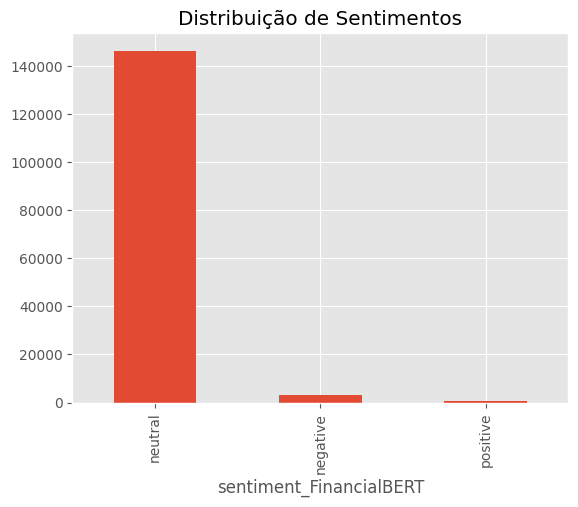

In [68]:
import matplotlib.pyplot as plt

df_sample["sentiment_FinancialBERT"].value_counts().plot(kind="bar")
plt.title("Distribuição de Sentimentos")
plt.show()

## Salvar dataset final

In [69]:
df_sample.to_csv("complaints_with_sentiment.csv", index=False)

## Exemplos de reclamações negativas

In [70]:
df_sample[df_sample["sentiment_FinancialBERT"]=="negative"]["narrative"].head(10)

28661     victim identity theft someone opened fraudulen...
83383     threatened called harassed debt lost job happe...
69229     purchased vacation company went bankrupt due c...
30740     feeling really ignored dispute bureau mailed l...
133768                        account identity theft belong
86206     lost wallet approximately ca since lot issue e...
50571                                 victim identity theft
27493                                 victim identity theft
21947        ftc violation sent ftc also violation attached
102722    navient reporting account late currently schoo...
Name: narrative, dtype: str

## Produtos com mais sentimento negativo

In [71]:
df_sample[df_sample["sentiment_FinancialBERT"]=="negative"]["product"].value_counts()

product
credit_reporting       2041
debt_collection         355
mortgages_and_loans     215
credit_card             201
retail_banking          138
Name: count, dtype: int64

## Média de confiança do modelo

In [87]:
# Estatísticas de confiança dos scores de sentimento por categoria
print("============= MEDIA =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].mean())
print("")
print("============= MEDIANA =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].median())
print("")
print("============= MODA =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].apply(lambda x: x.mode()))  # modo com apply
print("")
print("============= DESVIO PADRÃO =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].std())
print("")
print("============= VARIÂNCIA =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].var())
print("")
print("============= MÁXIMO =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].max())
print("")
print("============= MÍNIMO =====================")
print(df_sample.groupby("sentiment_FinancialBERT")["score"].min())


============= MEDIA =====================
sentiment_FinancialBERT
negative    0.849982
neutral     0.991741
positive    0.902136
Name: score, dtype: float64

============= MEDIANA =====================
sentiment_FinancialBERT
negative    0.889574
neutral     0.998792
positive    0.973721
Name: score, dtype: float64

============= MODA =====================
sentiment_FinancialBERT   
negative                 0    0.824081
neutral                  0    0.998981
positive                 0    0.999437
Name: score, dtype: float64

============= DESVIO PADRÃO =====================
sentiment_FinancialBERT
negative    0.145286
neutral     0.037860
positive    0.132790
Name: score, dtype: float64

============= VARIÂNCIA =====================
sentiment_FinancialBERT
negative    0.021108
neutral     0.001433
positive    0.017633
Name: score, dtype: float64

============= MÁXIMO =====================
sentiment_FinancialBERT
negative    0.999648
neutral     0.999844
positive    0.999760
Name: scor

In [88]:
# Estatisticas de confiança dos scores de sentimento por categoria e produto
print("============= MEDIA =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].mean())
print("")
print("============= MEDIANA =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].median())
print("")
print("============= MODA =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].apply(lambda x: x.mode()))  # modo com apply
print("")
print("============= DESVIO PADRÃO =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].std())
print("")
print("============= VARIÂNCIA =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].var())
print("")
print("============= MÁXIMO =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].max())
print("")
print("============= MÍNIMO =====================")
print(df_sample.groupby(["product", "sentiment_FinancialBERT"])["score"].min())

============= MEDIA =====================
product              sentiment_FinancialBERT
credit_card          negative                   0.867789
                     neutral                    0.992332
                     positive                   0.834474
credit_reporting     negative                   0.838367
                     neutral                    0.990777
                     positive                   0.925751
debt_collection      negative                   0.875132
                     neutral                    0.993311
                     positive                   0.872224
mortgages_and_loans  negative                   0.888790
                     neutral                    0.992514
                     positive                   0.862167
retail_banking       negative                   0.870672
                     neutral                    0.993715
                     positive                   0.878862
Name: score, dtype: float64

============= MEDIANA =======

A partir dos dados acima (grau de confiança), podemos separar as linhas com maior confiança e tomá-las como base para descobeta de características (insights).

In [86]:
# Proporção de cada categoria de sentimento dentro de cada produto.
pd.crosstab(
    df_sample["product"],
    df_sample["sentiment_FinancialBERT"],
    normalize="index"
)

sentiment_FinancialBERT,negative,neutral,positive
product,,,
credit_card,0.013983,0.981078,0.004939
credit_reporting,0.024238,0.970311,0.005451
debt_collection,0.016605,0.980355,0.003040
mortgages_and_loans,0.012260,0.983863,0.003878
retail_banking,0.011040,0.984240,0.004720


In [74]:
from typing import Counter

individual_counter = df_sample.apply(Counter)
individual_counter.head()

narrative                  {'lvnv funding llc sending communication easil...
clean_narrative            {'lvnv fund llc send commun easy op email requ...
sentiment_FinancialBERT    {'neutral': 146325, 'negative': 2950, 'positiv...
score                      {0.9979536533355713: 4, 0.9991649389266968: 7,...
product                    {'debt_collection': 21379, 'credit_reporting':...
dtype: object

In [58]:
#======================================================================================================
#======================================================================================================
#======================================================================================================

# Modelo RoBERTa sentiment

O RoBERTa (Robustly Optimized BERT Approach) é uma versão otimizada do BERT.

Ele foi treinado com mais dados, mais tempo de treinamento, estratégia de treinamento otimizada

Usa Byte-Pair Encoding (BPE) mais eficiente, que ajuda a lidar com palavras raras, erros de digitação e termos técnicos financeiros

In [51]:
# carregar o pipeline de análise de sentimentos usando um modelo pré-treinado específico para análises financeiras, 
# garantindo que ele utilize a GPU para acelerar o processamento.
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=0  # use GPU device 0; set -1 to force CPU
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
# verificar se a GPU está sendo utilizada corretamente, 
# imprimindo informações sobre a disponibilidade da GPU e o número de dispositivos disponíveis.
# Caso device=0 esteja configurado, o modelo deve usar a GPU. 
# Se a GPU não estiver disponível, ele irá automaticamente usar a CPU,

import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())

CUDA available: True
GPU device count: 1
Current device: 0


## Modelos BERT aceitam no máximo 512 tokens.
## Textos muito grandes podem causar erro.

In [53]:
texts = [t[:512] for t in texts]

In [54]:
print(len(texts))

162421


In [ ]:
results = sentiment_pipeline(
    texts,
    batch_size=256,
    truncation=True
)

In [ ]:
df_sample["sentiment_roberta"] = [r["label"] for r in results]
df_sample["score"] = [r["score"] for r in results]
df_sample.head()

,narrative,clean_narrative,sentiment_FinancialBERT,score,sentiment_FinancialBERT_binary,product,sentiment_roberta
5952,three credit reporting agency named creditor r...,three credit report ag nam credit refus coordi...,neutral,0.753958,negative,credit_reporting,neutral
153784,transunion incorrectly reporting day late part...,transun incorrect report day lat part account ...,neutral,0.691302,negative,credit_reporting,neutral
89184,disputed several collection item transunion to...,disput sev collect item transun today receiv r...,neutral,0.890268,negative,credit_reporting,neutral
7917,point sending complaint proof tried rectify on...,point send complaint proof tri rect ongo issu ...,neutral,0.816260,negative,credit_reporting,neutral
143941,may concern check credit see child support neg...,may concern check credit see child support neg...,neutral,0.800751,negative,credit_reporting,neutral


In [ ]:
df_sample["sentiment_roberta"].value_counts(normalize=True)

sentiment_roberta
neutral     0.7400
negative    0.2595
positive    0.0005
Name: proportion, dtype: float64

In [71]:
pd.crosstab(
    df_sample["product"],
    df_sample["sentiment_roberta"],
    normalize="index"
)

sentiment_roberta,negative,neutral,positive
product,,,
credit_card,0.165829,0.834171,0.000000
credit_reporting,0.308707,0.691293,0.000000
debt_collection,0.214545,0.785455,0.000000
mortgages_and_loans,0.133641,0.861751,0.004608
retail_banking,0.273256,0.726744,0.000000


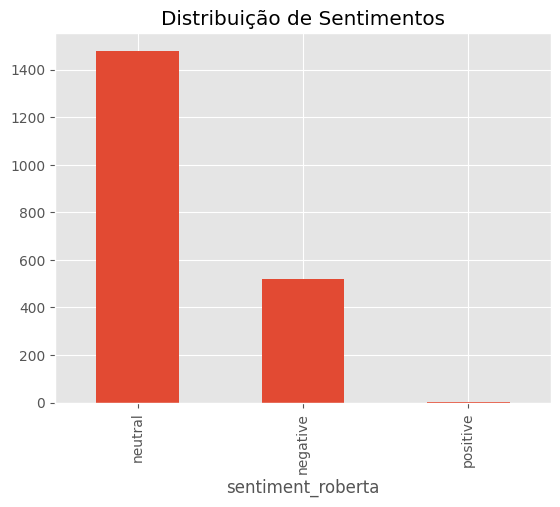

In [72]:
df_sample["sentiment_roberta"].value_counts().plot(kind="bar")
plt.title("Distribuição de Sentimentos")
plt.show()

In [73]:
df_sample["sentiment_roberta"].value_counts(normalize=True) * 100

sentiment_roberta
neutral     74.00
negative    25.95
positive     0.05
Name: proportion, dtype: float64

In [74]:
df_sample[df_sample["sentiment_roberta"]=="negative"]["narrative"].head(10)

49869     unverified fraudulent account following compan...
69640     reached comenity manytimes fix mistake made co...
140078    first time encountered identity theft pulled c...
27752     victim identity theft still account displayed ...
20826     one dont know people never gave permission go ...
133964    account listed belong someone social security ...
132908    fraudulent account credit report become egregi...
114283    looking credit report noticed sold outstanding...
42357     filed complaint guy pennymac trying scam peopl...
64967     missed payment due always pay full got dumped ...
Name: narrative, dtype: str

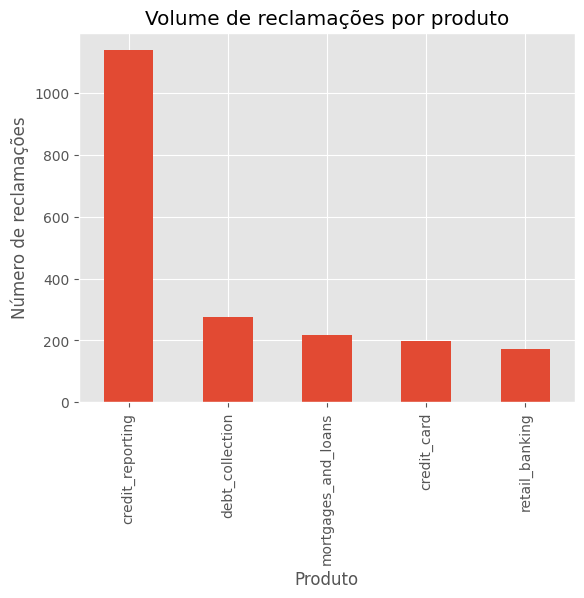

In [75]:
volume_product = df_sample["product"].value_counts()

volume_product.plot(kind="bar")

plt.title("Volume de reclamações por produto")
plt.ylabel("Número de reclamações")
plt.xlabel("Produto")

plt.show()

## Palavras mais comuns em reclamações negativas

In [76]:
negative_texts = df_sample[df_sample["sentiment_roberta"] == "negative"]["clean_narrative"]

text = " ".join(negative_texts)

In [77]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Palavras mais comuns em reclamações negativas")

plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [7]:
import pandas as pd
# carregar planilha completa com os sentimentos calculados e 
# verificar as primeiras linhas para garantir que os dados 
# foram salvos corretamente.
df_full = pd.read_csv("/home/paulo/projeto_tech_05/complaints_with_sentiment.csv")
df_full  # atribuir o DataFrame completo a uma variável mais curta
df_full.head()       # primeiras linhas
df_full.tail()       # últimas linhas
df_full.shape        # (linhas, colunas)
df_full.columns      # nomes das colunas
df_full.info()       # tipos + nulos
df_full.describe()   # estatísticas

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   product                  162421 non-null  str    
 1   narrative                162411 non-null  str    
 2   clean_narrative          162411 non-null  str    
 3   sentiment_FinancialBERT  162421 non-null  str    
 4   score                    162421 non-null  float64
dtypes: float64(1), str(4)
memory usage: 171.6 MB


,score
count,162421.000000
mean,0.988490
std,0.048297
min,0.432526
25%,0.996988
50%,0.998752
75%,0.999375
max,0.999844


In [8]:
# verificar a quantidade de valores nulos em cada coluna para 
# entender a qualidade dos dados e identificar possíveis problemas 
# de preenchimento.
print(df_full.isnull().sum())
df_full = df_full.dropna()
df_full.describe()   # estatísticas

product                     0
narrative                  10
clean_narrative            10
sentiment_FinancialBERT     0
score                       0
dtype: int64


,score
count,162411.000000
mean,0.988490
std,0.048298
min,0.432526
25%,0.996989
50%,0.998752
75%,0.999375
max,0.999844


In [9]:
# separar a planilha por produtos para análises específicas de cada categoria.
products = df_full["product"].unique()
dfs_por_produto = {produto: df_full[df_full["product"] == produto] for produto in products}

In [10]:
# gerar uma planilha para cada produto, 
# contendo apenas as reclamações e 
# os sentimentos relacionados a esse produto.
for produto, df_produto in dfs_por_produto.items():
    nome_arquivo = f"complaints_sentiment_{produto.replace(' ', '_')}.csv"
    df_produto.to_csv(nome_arquivo, index=False)
    print(f"Planilha gerada para {produto}: {nome_arquivo}")  

Planilha gerada para credit_card: complaints_sentiment_credit_card.csv
Planilha gerada para retail_banking: complaints_sentiment_retail_banking.csv
Planilha gerada para credit_reporting: complaints_sentiment_credit_reporting.csv
Planilha gerada para mortgages_and_loans: complaints_sentiment_mortgages_and_loans.csv
Planilha gerada para debt_collection: complaints_sentiment_debt_collection.csv


In [11]:
# Verificar os dados de cada planilha gerada para garantir que as informações estejam corretas e completas.
for produto, df_produto in dfs_por_produto.items():
    print(f"Verificando dados para {produto}...")
    print(df_produto.head())
    print(df_produto.info())
    print(df_produto.describe())
    print("\n")

Verificando dados para credit_card...
        product                                          narrative  \
0   credit_card  purchase order day shipping amount receive pro...   
1   credit_card  forwarded message date tue subject please inve...   
11  credit_card  called request new york state covid relief pla...   
12  credit_card  capital one secured credit account opened name...   
47  credit_card  issue concern discover credit card security de...   

                                      clean_narrative sentiment_FinancialBERT  \
0   purchas ord day ship amount receiv produc week...                 neutral   
1   forward mess dat tue subject pleas investig co...                 neutral   
11  cal request new york stat covid reliev plan da...                 neutral   
12  capit on sec credit account op nam clos outsta...                 neutral   
47  issu concern discov credit card sec deposit su...                 neutral   

       score  
0   0.998380  
1   0.997814  
11  0.998

In [12]:
# Carregar dados da planilha complaints_sentiment_credit_reporting or 
# service.csv para garantir que os dados estejam corretos e completos.
df_credit_report = pd.read_csv("complaints_sentiment_credit_reporting.csv")
df_credit_report.head()
df_credit_report.info()
df_credit_report.describe()

<class 'pandas.DataFrame'>
RangeIndex: 91172 entries, 0 to 91171
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  91172 non-null  str    
 1   narrative                91172 non-null  str    
 2   clean_narrative          91172 non-null  str    
 3   sentiment_FinancialBERT  91172 non-null  str    
 4   score                    91172 non-null  float64
dtypes: float64(1), str(4)
memory usage: 84.0 MB


,score
count,91172.000000
mean,0.986690
std,0.052840
min,0.469590
25%,0.997080
50%,0.998864
75%,0.999413
max,0.999844


In [13]:
# Carregar dados da planilha complaints_sentiment_credit_card or 
# service.csv para garantir que os dados estejam corretos e completos.
df_credit_card = pd.read_csv("complaints_sentiment_credit_card.csv")
df_credit_card.head()
df_credit_card.info()
df_credit_card.describe()   

<class 'pandas.DataFrame'>
RangeIndex: 15566 entries, 0 to 15565
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  15566 non-null  str    
 1   narrative                15566 non-null  str    
 2   clean_narrative          15566 non-null  str    
 3   sentiment_FinancialBERT  15566 non-null  str    
 4   score                    15566 non-null  float64
dtypes: float64(1), str(4)
memory usage: 19.3 MB


,score
count,15566.000000
mean,0.989644
std,0.045111
min,0.432526
25%,0.996632
50%,0.998503
75%,0.999245
max,0.999828


In [14]:
# Carregar dados da planilha complaints_sentiment_debt_colletion or 
# service.csv para garantir que os dados estejam corretos e completos.
df_debt_collection = pd.read_csv("complaints_sentiment_debt_collection.csv")
df_debt_collection.head()
df_debt_collection.info()   
df_debt_collection.describe()   

<class 'pandas.DataFrame'>
RangeIndex: 23148 entries, 0 to 23147
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  23148 non-null  str    
 1   narrative                23148 non-null  str    
 2   clean_narrative          23148 non-null  str    
 3   sentiment_FinancialBERT  23148 non-null  str    
 4   score                    23148 non-null  float64
dtypes: float64(1), str(4)
memory usage: 24.0 MB


,score
count,23148.000000
mean,0.991049
std,0.041961
min,0.490084
25%,0.997387
50%,0.998880
75%,0.999448
max,0.999829


In [15]:
# Carregar dados da planilha complaints_sentiment_mortgages_and_loans or 
# service.csv para garantir que os dados estejam corretos e completos.
df_mortgages_loans = pd.read_csv("complaints_sentiment_mortgages_and_loans.csv")
df_mortgages_loans.head()
df_mortgages_loans.info()   
df_mortgages_loans.describe()

<class 'pandas.DataFrame'>
RangeIndex: 18990 entries, 0 to 18989
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  18990 non-null  str    
 1   narrative                18990 non-null  str    
 2   clean_narrative          18990 non-null  str    
 3   sentiment_FinancialBERT  18990 non-null  str    
 4   score                    18990 non-null  float64
dtypes: float64(1), str(4)
memory usage: 28.2 MB


,score
count,18990.000000
mean,0.990730
std,0.040529
min,0.470433
25%,0.996430
50%,0.998383
75%,0.999164
max,0.999837


In [16]:
# Carregar dados da planilha complaints_sentiment_retail_banking or 
# service.csv para garantir que os dados estejam corretos e completos.
df_retail_banking = pd.read_csv("complaints_sentiment_retail_banking.csv")
df_retail_banking.head()
df_retail_banking.info()   
df_retail_banking.describe()

<class 'pandas.DataFrame'>
RangeIndex: 13535 entries, 0 to 13534
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  13535 non-null  str    
 1   narrative                13535 non-null  str    
 2   clean_narrative          13535 non-null  str    
 3   sentiment_FinancialBERT  13535 non-null  str    
 4   score                    13535 non-null  float64
dtypes: float64(1), str(4)
memory usage: 16.0 MB


,score
count,13535.000000
mean,0.991769
std,0.038419
min,0.495954
25%,0.997020
50%,0.998664
75%,0.999345
max,0.999823


In [17]:
# No arquivos csv complaints_sentiment_retail_banking separar os dados segundo a catagoria de sentiment_FinancialBERT para análises específicas de cada categoria.
df_retail_banking_positive = df_retail_banking[df_retail_banking['sentiment_FinancialBERT'] == 'positive']
df_retail_banking_negative = df_retail_banking[df_retail_banking['sentiment_FinancialBERT'] == 'negative']
df_retail_banking_neutral = df_retail_banking[df_retail_banking['sentiment_FinancialBERT'] == 'neutral']   

In [18]:
          # Transforma o dataframe df_retail_banking_positive em um arquivo csv para análises específicas de reclamações positivas no produto de retail banking.
df_retail_banking_positive.to_csv("complaints_sentiment_retail_banking_positive.csv", index=False)  

          # Transforma o dataframe df_retail_banking_negative em um arquivo csv para análises específicas de reclamações negativas no produto de retail banking.
df_retail_banking_negative.to_csv("complaints_sentiment_retail_banking_negative.csv", index=False)  

          # Transforma o dataframe df_retail_banking_neutral em um arquivo csv para análises específicas de reclamações neutras no produto de retail banking.
df_retail_banking_neutral.to_csv("complaints_sentiment_retail_banking_neutral.csv", index=False)  

In [6]:
# foi rodado o comando >>>"pip install transformers torch pandas tqdm" <<<,
# na linha de comando do VScode, para garantir que as bibliotecas necessárias
# para tradução de textos usando um modelo pré-treinado da Hugging Face 
# estejam instaladas corretamente no ambiente.

# importar bibliotecas necessárias para tradução de textos usando um modelo 
# pré-treinado da Hugging Face,
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm

In [7]:
# Configurar para usar GPU se disponível
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [8]:
# Carregar o modelo e tokenizer para tradução EN -> PT
model_name = "Helsinki-NLP/opus-mt-en-ROMANCE"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)

/home/paulo/projeto_tech_05/venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [ ]:
# # Testar diferentes valores executando este código de diagnóstico:
# import torch
# from transformers import MarianMTModel, MarianTokenizer

# def test_batch_size(model, tokenizer, test_texts, batch_size):
#     """Testa se um batch_size específico cabe na GPU"""
#     try:
#         inputs = tokenizer(test_texts, return_tensors="pt", padding=True, truncation=True).to("cuda")
#         with torch.no_grad():
#             outputs = model.generate(**inputs)
#         print(f"✅ Batch size {batch_size} funcionou!")
#         return True
#     except torch.cuda.OutOfMemoryError:
#         print(f"❌ Batch size {batch_size} estourou a memória")
#         torch.cuda.empty_cache()
#         return False

# # Carregar modelo
# model_name = "Helsinki-NLP/opus-mt-en-ROMANCE"
# tokenizer = MarianTokenizer.from_pretrained(model_name)
# model = MarianMTModel.from_pretrained(model_name).to("cuda")

# # Testar diferentes batch sizes com textos de tamanho real
# textos_teste = ["This is a test sentence."] * 32  # Cria 32 frases iguais para teste

# # Teste progressivo
# for bs in [8, 12, 16, 20, 24, 32, 48, 64, 128, 256, 512, 1024]:
#     test_batch_size(model, tokenizer, textos_teste[:bs], bs)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Batch size 8 funcionou!
✅ Batch size 12 funcionou!
✅ Batch size 16 funcionou!
✅ Batch size 20 funcionou!
✅ Batch size 24 funcionou!
✅ Batch size 32 funcionou!
✅ Batch size 48 funcionou!
✅ Batch size 64 funcionou!
✅ Batch size 128 funcionou!
✅ Batch size 256 funcionou!
✅ Batch size 512 funcionou!
✅ Batch size 1024 funcionou!


In [16]:
# definir uma função para traduzir uma lista de textos do inglês para o português,
def translate_batch(texts, batch_size=16):
    """
    Traduz uma lista de textos do inglês para o português.
    Processa em lotes (batches) para melhor performance.
    """
    translations = []
    
    # Processar em batches
    for i in tqdm(range(0, len(texts), batch_size), desc="Traduzindo"):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenizar os textos
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            padding=True, 
            truncation=True, 
            max_length=512
        ).to(device)
        
        # Gerar traduções
        with torch.no_grad():
            generated = model.generate(**inputs)
        
        # Decodificar os resultados
        batch_translations = tokenizer.batch_decode(generated, skip_special_tokens=True)
        translations.extend(batch_translations)
    
    return translations


In [17]:
# Verificar se a GPU está disponível
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU disponível: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# import torch
# import gc

# # 1. Remova as variáveis pesadas (substitua pelos nomes dos seus objetos)
# del model_name
# del tokenizer
# del model

# # 2. Limpe o lixo da memória RAM
# gc.collect()

# # 3. Esvazie o cache da GPU para o nvidia-smi mostrar como livre
#torch.cuda.empty_cache()

# # model_name = "Helsinki-NLP/opus-mt-en-ROMANCE"
# # tokenizer = MarianTokenizer.from_pretrained(model_name)
# # model = MarianMTModel.from_pretrained(model_name).to(device)


In [18]:
# transformar o arquivo csv em um DataFrame para facilitar a manipulação dos dados.
df_retail_banking_positive = pd.read_csv("complaints_sentiment_retail_banking_positive.csv")   

In [19]:
df_retail_banking_positive.head(3)

,product,narrative,clean_narrative,sentiment_FinancialBERT,score
0,retail_banking,account wont link pnc need pnc wont let save e...,account wont link pnc nee pnc wont let sav eith,positive,0.999597
1,retail_banking,ach deposit arkansas bofa small bussines accou...,ach deposit arkansa bof smal bussin account ll...,positive,0.586481
2,retail_banking,present time making deposit least jpay account...,pres tim mak deposit least jpay account stat f...,positive,0.717757


In [20]:
df_retail_banking_positive.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  64 non-null     str    
 1   narrative                64 non-null     str    
 2   clean_narrative          64 non-null     str    
 3   sentiment_FinancialBERT  64 non-null     str    
 4   score                    64 non-null     float64
dtypes: float64(1), str(4)
memory usage: 36.3 KB


In [21]:
# Carregar os textos a serem traduzidos 
# (exemplo usando a coluna "narrative" do arquivo csv gerado anteriormente)
texts = df_retail_banking_positive["narrative"].tolist()

In [22]:
# Liberar memória de GPU antes de traduzir
torch.cuda.empty_cache()

# Traduzir todos os textos em lotes menores para evitar OOM
textos_traduzidos = translate_batch(
	df_retail_banking_positive['narrative'].tolist(),
	batch_size=1
)

# Adicionar a coluna traduzida ao DataFrame
df_retail_banking_positive['texto_portugues'] = textos_traduzidos

# Visualizar o resultado
print("\nResultados:")
print(df_retail_banking_positive[['narrative', 'texto_portugues']].head())

Traduzindo: 100%|██████████| 64/64 [01:04<00:00,  1.01s/it]


Resultados:
                                           narrative  \
0  account wont link pnc need pnc wont let save e...   
1  ach deposit arkansas bofa small bussines accou...   
2  present time making deposit least jpay account...   
3  cant link pnc checking account pnc wont allow ...   
4  chime decided close account reached retrieve d...   

                                     texto_portugues  
0  account will link pnc need pnc will will lat s...  
1  ach deposit arkansas bofa petit bussines compt...  
2  presente hora de depósito menos jpay cuenta de...  
3  cant link pnc check account pnc no permitirá c...  
4  chime decidió close account touch recuper depo...  


In [24]:
df_retail_banking_positive.tail(3)

,product,narrative,clean_narrative,sentiment_FinancialBERT,score,texto_portugues
61,retail_banking,wont give access attach account help finance week,wont giv access attach account help fin week,positive,0.789813,no darán acceso acceso annexo de cuenta de ayu...
62,retail_banking,trying link pnc bank account pnc wont allow ca...,try link pnc bank account pnc wont allow cant ...,positive,0.875579,tentando link pnc banco pnc conto pnc no permi...
63,retail_banking,advertises benefit partnering deal providing f...,advert benefit partn deal provid fin pay gross...,positive,0.988593,anuncie Benefit Partnering Deal providenciando...


# Gerando frases positivas a partir de todas as frases positivas reais. Não traduziu porcaria nenhuma.


In [39]:
# tranformar o arquivo csv complaints_with_sentiment.csv em um um dataframe para análises específicas de reclamações positivas.
df_complaints = pd.read_csv("complaints_with_sentiment.csv")
df_complaints.info()
df_complaints.head()

<class 'pandas.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   product                  162421 non-null  str    
 1   narrative                162411 non-null  str    
 2   clean_narrative          162411 non-null  str    
 3   sentiment_FinancialBERT  162421 non-null  str    
 4   score                    162421 non-null  float64
dtypes: float64(1), str(4)
memory usage: 171.6 MB


,product,narrative,clean_narrative,sentiment_FinancialBERT,score
0,credit_card,purchase order day shipping amount receive pro...,purchas ord day ship amount receiv produc week...,neutral,0.998380
1,credit_card,forwarded message date tue subject please inve...,forward mess dat tue subject pleas investig co...,neutral,0.997814
2,retail_banking,forwarded message cc sent friday pdt subject f...,forward mess cc sent friday pdt subject fin le...,neutral,0.985487
3,credit_reporting,payment history missing credit report speciali...,pay hist miss credit report spec loan serv sl ...,neutral,0.995491
4,credit_reporting,payment history missing credit report made mis...,pay hist miss credit report mad mistak put acc...,neutral,0.995610


In [42]:
# No data frame df_complaints separar os dados segundo a catagoria de sentiment_FinancialBERT iguais a "positive". para análises específicas de cada categoria.
df_positive = df_complaints[df_complaints['sentiment_FinancialBERT'] == 'positive']
df_positive.info()
df_positive.head()  

<class 'pandas.DataFrame'>
Index: 779 entries, 1779 to 162285
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  779 non-null    str    
 1   narrative                779 non-null    str    
 2   clean_narrative          779 non-null    str    
 3   sentiment_FinancialBERT  779 non-null    str    
 4   score                    779 non-null    float64
dtypes: float64(1), str(4)
memory usage: 425.6 KB


,product,narrative,clean_narrative,sentiment_FinancialBERT,score
1779,credit_reporting,delinquent debt paid since credit bureau updat...,delinqu debt paid sint credit bureau upd recor...,positive,0.903719
1780,credit_reporting,delinquent debt paid since credit bureau updat...,delinqu debt paid sint credit bureau upd recor...,positive,0.903719
2209,credit_card,scam artist created post looked like branch ap...,scam art cre post look lik branch ap invit joi...,positive,0.517733
2586,credit_card,two year ago clear blue sky capital one arbitr...,two year ago clear blu sky capit on arbit deci...,positive,0.631005
3823,retail_banking,account wont link pnc need pnc wont let save e...,account wont link pnc nee pnc wont let sav eith,positive,0.999597


In [43]:
# usado no OLLAMA.
texts_positive = df_positive["narrative"].tolist()

In [45]:
# transforar texts_positive em arquivo csv para análises específicas de reclamações positivas.
df_positive.to_csv("complaints_positive.csv", index=False)


In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

novas_frases = []

for _ in range(500):  # 500 vezes
    textos = generator(
        "The bank service was excellent and",
        max_length=50,
        num_return_sequences=10,   # gera 10 de uma vez
        temperature=0.9,           # criatividade
        top_k=50,
        top_p=0.95,
        do_sample=True
    )
    
    for t in textos:
        novas_frases.append(t["generated_text"])
frases_limpas = []

for frase in novas_frases:
    frase = frase.replace("The bank service was excellent and", "")
    frases_limpas.append(frase.strip())

import pandas as pd

df = pd.DataFrame(frases_limpas, columns=["texto"])
df.to_csv("frases_geradas.csv", index=False)
df = pd.read_csv("frases_geradas.csv")

# Usando OLLAMA para gerar frases positivas.

In [ ]:
import pandas as pd
import ollama
from tqdm import tqdm
import time

def gerar_variacoes_local(frase_original, num_variacoes=3):
    """
    Gera variações de frases usando DeepSeek rodando localmente.
    """
    prompt = f"""
    Frase original: "{frase_original}"
    
    Gere {num_variacoes} versões diferentes desta frase, mantendo o mesmo significado,
    em Ingles. Responda apenas com as frases, uma por linha.
    """
    
    try:
        response = ollama.chat(
            model='deepseek-r1:8b',  # ou o modelo que você baixou
            messages=[
                {'role': 'system', 'content': 'Você é um assistente que gera variações de textos.'},
                {'role': 'user', 'content': prompt}
            ],
            options={
                'temperature': 0.8,
                'num_predict': 200
            }
        )
        
        resultado = response['message']['content'].strip()
        variacoes = [linha.strip() for linha in resultado.split('\n') if linha.strip()]
        
        # Limpar possíveis marcações como "1.", "2." etc.
        variacoes_limpas = []
        for v in variacoes:
            # Remove numerações iniciais
            import re
            v_limpa = re.sub(r'^\d+[\.\)]\s*', '', v)
            variacoes_limpas.append(v_limpa)
        
        return variacoes_limpas[:num_variacoes]
        
    except Exception as e:
        print(f"Erro: {e}")
        return [f"Erro: {frase_original}"] * num_variacoes

# ============================================
# Processamento similar ao anterior
# ============================================

df = pd.read_csv('complaints_positive.csv')

# Identifique sua coluna de texto
coluna_texto = df.columns[1]  # ou especifique pelo nome
print(f"Processando coluna: {coluna_texto}")

novas_frases = []
frases_originais = []

for idx, row in tqdm(df.head(50).iterrows(), total=50, desc="Testando"):  # Comece com 50 para testar
    frase = row[coluna_texto]
    variacoes = gerar_variacoes_local(frase, num_variacoes=9)
    
    for variacao in variacoes:
        novas_frases.append(variacao)
        frases_originais.append(frase)

df_resultado = pd.DataFrame({
    'frase_original': frases_originais,
    'frase_gerada': novas_frases
})

df_resultado.to_csv('frases_geradas_local.csv', index=False, encoding='utf-8')
print(f"✅ Geradas {len(df_resultado)} frases!")
#Erro: model requires more system memory (5.5 GiB) than is available (2.8 GiB) (status code: 500)

Processando coluna: narrative


Testando:   0%|          | 0/50 [00:00<?, ?it/s]

Testando:   2%|▏         | 1/50 [00:01<01:20,  1.65s/it]

Erro: model requires more system memory (5.5 GiB) than is available (2.9 GiB) (status code: 500)


Testando:   4%|▍         | 2/50 [00:01<00:41,  1.15it/s]

...

Erro: model requires more system memory (5.5 GiB) than is available (2.9 GiB) (status code: 500)


Testando:  98%|█████████▊| 49/50 [00:16<00:00,  3.23it/s]

Erro: model requires more system memory (5.5 GiB) than is available (2.9 GiB) (status code: 500)


Testando: 100%|██████████| 50/50 [00:16<00:00,  3.00it/s]

Erro: model requires more system memory (5.5 GiB) than is available (2.8 GiB) (status code: 500)
✅ Geradas 450 frases!
